# 11 — Prompt Variation Experiment (OpenAI Baseline)

Notebook ini melakukan **prompt ablation study** pada konfigurasi Baseline Hybrid (BM25+Dense → top-5 → LLM) dengan **4 variasi prompt** untuk identifikasi prompt mana yang optimal.

## Tujuan

Jawab pertanyaan: *"Prompt seperti apa yang paling efektif untuk task PubMedQA yes/no/maybe?"*

Setelah eksperimen ini, hasil terbaik bisa di-generalize ke konfigurasi lain (QR, CR, AHD) di tahap berikutnya.

## 4 Variasi Prompt

| ID | Nama | Karakteristik |
|---|---|---|
| **P1** | Current (Strict) | Definitive, prefer yes/no, zero-shot — same as notebook 02.1 |
| **P2** | Few-shot ICL | 3 contoh in-context (yes, no, maybe) sebelum target query |
| **P3** | Chain-of-Thought | Force step-by-step reasoning (identify → search → assess → conclude) |
| **P4** | Conservative | Less definitive, neutral acceptance of "maybe" |

## Konfigurasi

| Parameter | Nilai |
|---|---|
| Retriever | Hybrid BM25 top-50 + Dense top-50 → RRF → top-5 |
| LLM | gpt-4.1-mini |
| Sample size | 100 (sama dengan AHD untuk apple-to-apple) |
| Temperature | 0.0 (deterministik) |
| Seed | 42 |

## Output

- `results/prompt_p1_phase1.json` ... `prompt_p4_phase1.json` (Phase 1 per prompt)
- `results/prompt_p1_phase2.json` ... `prompt_p4_phase2.json` (RAGAS per prompt)
- `figures/K_prompt_variation.png` — comparison visualization

## Cost & Waktu

- 4 prompts × 100 sampel × ~1 generation call = 400 calls
- Phase 2 RAGAS: 4 × 100 × ~12 calls = ~4800 calls
- **Total: ~5200 calls = ~$3-5 OpenAI, runtime ~2 jam**


## Cell 1 — Imports & Konfigurasi

In [1]:
import os, sys, json, pickle, time, re, warnings
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from pathlib import Path
from datetime import datetime

from openai import OpenAI
from rank_bm25 import BM25Okapi
import chromadb

warnings.filterwarnings('ignore')

# ============================================================
# KONFIGURASI
# ============================================================
OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', 'YOUR_OPENAI_KEY_HERE')

LLM_MODEL   = 'gpt-4.1-mini'
EMBED_MODEL = 'text-embedding-3-small'

# Hybrid retrieval (sama dengan notebook 02.1)
TOP_K_BM25      = 50
TOP_K_DENSE     = 50
TOP_K_RETRIEVAL = 5

# Sample size
MAX_SAMPLES = 100

TEMPERATURE = 0.0
SEED        = 42

# Prompt IDs to test
PROMPT_IDS = ['P1', 'P2', 'P3', 'P4']
PROMPT_NAMES = {
    'P1': 'Current (Strict)',
    'P2': 'Few-shot (ICL)',
    'P3': 'Chain-of-Thought',
    'P4': 'Conservative',
}

NOTEBOOK_DIR    = Path('.')
BM25_INDEX_PATH = NOTEBOOK_DIR / 'pubmedqa_bm25.pkl'
CHROMA_DB_PATH  = NOTEBOOK_DIR / 'pubmedqa_chroma'
RESULTS_DIR     = Path('../results')
FIGURES_DIR     = NOTEBOOK_DIR / 'figures'
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

print('Konfigurasi:')
print(f'  LLM             : {LLM_MODEL}')
print(f'  Embedder        : {EMBED_MODEL}')
print(f'  Hybrid          : BM25 top-{TOP_K_BM25} + Dense top-{TOP_K_DENSE} -> RRF -> top-{TOP_K_RETRIEVAL}')
print(f'  Sampel          : {MAX_SAMPLES}')
print(f'  Prompts to test : {", ".join(PROMPT_IDS)}')
print()
if 'YOUR_API_KEY' in OPENAI_API_KEY:
    print('  OPENAI_API_KEY belum diset!')
else:
    print(f'  OPENAI_API_KEY  : {OPENAI_API_KEY[:8]}...{OPENAI_API_KEY[-4:]}')

Konfigurasi:
  LLM             : gpt-4.1-mini
  Embedder        : text-embedding-3-small
  Hybrid          : BM25 top-50 + Dense top-50 -> RRF -> top-5
  Sampel          : 100
  Prompts to test : P1, P2, P3, P4

  OPENAI_API_KEY  : sk-proj-...REDACTED


## Cell 2 — Load BM25, ChromaDB, PubMedQA Test Set

In [2]:
@dataclass
class Document:
    text         : str
    pubid        : str
    question     : str
    section_label: str
    answer       : str
    decision     : str

def tokenize_bm25(text: str) -> List[str]:
    return re.sub(r'[^a-zA-Z0-9\s]', ' ', text.lower()).split()

# Load BM25
print('Loading BM25 index...')
with open(BM25_INDEX_PATH, 'rb') as f:
    bm25_data = pickle.load(f)
bm25_index = bm25_data['bm25']
documents  = bm25_data['documents']
print(f'  BM25: {len(documents)} dokumen')

# Load Chroma
print('Loading ChromaDB collection...')
chroma_client = chromadb.PersistentClient(path=str(CHROMA_DB_PATH))
chroma_collection = chroma_client.get_collection(name='pubmedqa_docs')
print(f'  Chroma: {chroma_collection.count()} dokumen')

# Load PubMedQA test data
print('Loading PubMedQA test set...')
import csv
PUBMEDQA_CSV = Path('../data/pubmedqa_pqa_labeled.csv')
test_samples = []
with open(PUBMEDQA_CSV, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_samples.append({
            'idx'           : len(test_samples),
            'pubid'         : row['pubid'],
            'question'      : row['question'],
            'final_decision': row['final_decision'],
            'long_answer'   : row['long_answer'],
        })
        if len(test_samples) >= MAX_SAMPLES:
            break
print(f'  Loaded {len(test_samples)} test samples')

# Distribusi label di subset 100
from collections import Counter
dist = Counter(s['final_decision'] for s in test_samples)
print(f'\nLabel distribution di {MAX_SAMPLES} sampel:')
for lbl in ['yes', 'no', 'maybe']:
    print(f'  {lbl:>5}: {dist[lbl]:3d} ({dist[lbl]/MAX_SAMPLES:.0%})')

Loading BM25 index...
  BM25: 1706 dokumen
Loading ChromaDB collection...
  Chroma: 1706 dokumen
Loading PubMedQA test set...
  Loaded 100 test samples

Label distribution di 100 sampel:
    yes:  58 (58%)
     no:  26 (26%)
  maybe:  16 (16%)


## Cell 3 — OpenAI Client & Hybrid Retrieval Helpers

In [3]:
openai_client = OpenAI(api_key=OPENAI_API_KEY)

def openai_generate(prompt: str, max_tokens: int = 500, temperature: float = TEMPERATURE) -> str:
    for attempt in range(5):
        try:
            r = openai_client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                temperature=temperature, max_tokens=max_tokens, seed=SEED,
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            if attempt == 4: raise
            time.sleep((attempt + 1) * 5)
    raise RuntimeError('llm gagal')

def openai_embed(texts: List[str]) -> List[List[float]]:
    for attempt in range(5):
        try:
            r = openai_client.embeddings.create(model=EMBED_MODEL, input=texts)
            return [d.embedding for d in r.data]
        except Exception as e:
            if attempt == 4: raise
            time.sleep((attempt + 1) * 5)
    raise RuntimeError('embed gagal')

def retrieve_dense(query: str, k: int) -> List[Tuple[int, float]]:
    qvec = openai_embed([query])[0]
    r = chroma_collection.query(query_embeddings=[qvec], n_results=k, include=['distances'])
    doc_ids   = [int(i) for i in r['ids'][0]]
    distances = r['distances'][0]
    return [(d, 1.0 - dist) for d, dist in zip(doc_ids, distances)]

def retrieve_bm25(query: str, k: int) -> List[Tuple[int, float]]:
    tokens = tokenize_bm25(query)
    scores = bm25_index.get_scores(tokens)
    top    = np.argsort(scores)[::-1][:k]
    return [(int(i), float(scores[i])) for i in top]

def reciprocal_rank_fusion(rank_lists: List[List[int]], k: int = 60) -> List[Tuple[int, float]]:
    s = {}
    for rl in rank_lists:
        for rank, did in enumerate(rl):
            s[did] = s.get(did, 0.0) + 1.0 / (k + rank + 1)
    return sorted(s.items(), key=lambda x: -x[1])

def hybrid_retrieve(query: str, top_k: int = TOP_K_RETRIEVAL) -> List[Dict]:
    bm25_pairs  = retrieve_bm25(query, k=TOP_K_BM25)
    dense_pairs = retrieve_dense(query, k=TOP_K_DENSE)
    bm25_scores  = dict(bm25_pairs)
    dense_scores = dict(dense_pairs)
    fused = reciprocal_rank_fusion([
        [d for d, _ in bm25_pairs],
        [d for d, _ in dense_pairs],
    ])
    out = []
    for doc_id, rrf_score in fused[:top_k]:
        d = documents[doc_id]
        out.append({
            'doc_id' : doc_id,
            'text'   : d.text,
            'section': d.section_label,
            'bm25'   : bm25_scores.get(doc_id, 0.0),
            'dense'  : dense_scores.get(doc_id, 0.0),
            'rrf'    : rrf_score,
        })
    return out

print('Retrieval helpers ready.')

Retrieval helpers ready.


## Cell 4 — Definisi 4 Variasi Prompt

Tiap prompt menerima `{context}` (top-5 docs) dan `{question}`, return text yang berakhir dengan yes/no/maybe.

In [4]:
# ============================================================
# P1 — Current / Strict (sama dengan notebook 02.1)
# ============================================================
PROMPT_P1 = (
    'You are a medical research assistant. '
    'Answer a biomedical yes/no/maybe question based solely on the provided scientific abstracts.\n\n'
    'Context from medical literature:\n{context}\n\n'
    'Question: {question}\n\n'
    'Instructions:\n'
    '- Carefully read the context and assess whether it supports or refutes the question.\n'
    '- Provide a brief explanation (2-3 sentences) using ONLY the information above.\n'
    '- End your response with EXACTLY ONE of these words on its own line: yes, no, or maybe.\n'
    '  - yes   : the evidence supports the hypothesis, even if not perfectly conclusive\n'
    '  - no    : the evidence refutes or does not support the hypothesis\n'
    '  - maybe : ONLY if the evidence is directly contradictory (some findings say yes,\n'
    '            others say no), or if the context contains no relevant information at all\n'
    '- IMPORTANT: If the evidence leans in one direction, even partially, choose yes or no.\n'
    '  Do NOT use maybe simply because the evidence is limited or not 100% certain.\n\n'
    'Answer:'
)

# ============================================================
# P2 — Few-shot ICL (3 contoh sebelum target)
# ============================================================
PROMPT_P2 = (
    'You are a medical research assistant. '
    'Answer biomedical yes/no/maybe questions based solely on the provided scientific abstracts.\n\n'
    'Below are 3 examples to follow:\n\n'
    '=== EXAMPLE 1 ===\n'
    'Context: A randomized controlled trial enrolled 5,000 patients aged 60+. '
    'Daily aspirin therapy reduced cardiovascular mortality by 15% '
    '(95% CI: 8-22%, p<0.001) over 5-year follow-up.\n'
    'Question: Does aspirin reduce cardiovascular mortality in elderly patients?\n'
    'Answer: The evidence shows a statistically significant 15% reduction in '
    'cardiovascular mortality with aspirin therapy (p<0.001). The effect is '
    'consistent across the elderly population studied.\n'
    'yes\n\n'
    '=== EXAMPLE 2 ===\n'
    'Context: A meta-analysis of 8 randomized trials found no significant '
    'association between vitamin C supplementation and common cold prevention '
    '(RR=0.97, 95% CI: 0.89-1.06). The pooled estimate crossed unity.\n'
    'Question: Does vitamin C supplementation prevent common cold in healthy adults?\n'
    'Answer: The pooled evidence from 8 trials shows no significant association '
    'between vitamin C supplementation and cold prevention. The confidence '
    'interval crosses 1.0, indicating no effect.\n'
    'no\n\n'
    '=== EXAMPLE 3 ===\n'
    'Context: Some observational studies report HPV vaccination reduces cervical '
    'cancer incidence by 80% in young women, while others find only 40% reduction '
    'in older cohorts. Effect varies substantially by age and follow-up duration.\n'
    'Question: Does HPV vaccination reduce cervical cancer?\n'
    'Answer: Studies report contradictory effect sizes (80% vs 40%) depending on '
    'age cohort. The evidence does not converge on a single conclusion.\n'
    'maybe\n\n'
    '=== NOW ANSWER THIS QUESTION ===\n'
    'Context: {context}\n\n'
    'Question: {question}\n\n'
    'Provide a brief explanation (2-3 sentences) using ONLY the context above. '
    'End with EXACTLY ONE word on its own line: yes, no, or maybe.\n\n'
    'Answer:'
)

# ============================================================
# P3 — Chain-of-Thought (step-by-step reasoning)
# ============================================================
PROMPT_P3 = (
    'You are a medical research assistant. '
    'Answer the biomedical yes/no/maybe question through structured step-by-step reasoning.\n\n'
    'Context from medical literature:\n{context}\n\n'
    'Question: {question}\n\n'
    'Reasoning steps (follow this format):\n\n'
    'Step 1 — Identify the key claim: What specific relationship or fact is the '
    'question testing?\n\n'
    'Step 2 — Search for supporting evidence: Which passages in the context '
    'support the claim? Quote the most relevant passage.\n\n'
    'Step 3 — Search for refuting evidence: Are there any passages that contradict '
    'the claim? Quote them if found.\n\n'
    'Step 4 — Assess the evidence: Does the context support, refute, or is it '
    'insufficient/contradictory?\n\n'
    'Step 5 — Conclude: End your response with EXACTLY ONE word on its own line: '
    'yes, no, or maybe.\n'
    '  - yes   : evidence supports (even partially)\n'
    '  - no    : evidence refutes or does not support\n'
    '  - maybe : evidence is directly contradictory OR no relevant info found\n\n'
    'Reasoning:'
)

# ============================================================
# P4 — Conservative (less definitive, allow honest maybe)
# ============================================================
PROMPT_P4 = (
    'You are a medical research assistant. '
    'Answer biomedical yes/no/maybe questions based on the provided scientific abstracts.\n\n'
    'Context from medical literature:\n{context}\n\n'
    'Question: {question}\n\n'
    'Instructions:\n'
    '- Read the context carefully and assess what it supports.\n'
    '- Provide a brief explanation (2-3 sentences) using ONLY the information above.\n'
    '- End your response with EXACTLY ONE word on its own line: yes, no, or maybe.\n'
    '  - yes   : the evidence clearly supports the hypothesis\n'
    '  - no    : the evidence clearly refutes the hypothesis\n'
    '  - maybe : the evidence is unclear, contradictory, partial, or insufficient\n\n'
    'Note: Honest uncertainty is acceptable. If the evidence is genuinely ambiguous, '
    'limited, or you cannot confidently commit to yes or no, "maybe" is a valid answer.\n\n'
    'Answer:'
)

PROMPTS = {
    'P1': PROMPT_P1,
    'P2': PROMPT_P2,
    'P3': PROMPT_P3,
    'P4': PROMPT_P4,
}

print('4 prompt templates loaded:')
for pid, name in PROMPT_NAMES.items():
    n_chars = len(PROMPTS[pid])
    print(f'  {pid} ({name:<22}): {n_chars} chars')

4 prompt templates loaded:
  P1 (Current (Strict)      ): 959 chars
  P2 (Few-shot (ICL)        ): 1809 chars
  P3 (Chain-of-Thought      ): 937 chars
  P4 (Conservative          ): 782 chars


## Cell 5 — Generation Function & Label Extraction

In [5]:
def generate_with_prompt(prompt_id: str, question: str, contexts: List[Dict]) -> str:
    """Generate answer pakai prompt_id (P1/P2/P3/P4) dan top-5 contexts."""
    ctx_text = '\n\n'.join(
        f'[{i+1}] ({c["section"]}): {c["text"]}'
        for i, c in enumerate(contexts)
    )
    prompt = PROMPTS[prompt_id].format(context=ctx_text, question=question)
    # P3 (CoT) butuh max_tokens lebih besar karena reasoning panjang
    max_tok = 800 if prompt_id == 'P3' else 400
    return openai_generate(prompt, max_tokens=max_tok)

def extract_label(answer: str) -> str:
    """Extract yes/no/maybe label from answer text."""
    lines = [l.strip().lower() for l in answer.split('\n') if l.strip()]
    for line in reversed(lines[-5:]):  # cek 5 baris terakhir untuk CoT
        word = re.sub(r'[^a-z]', '', line)
        if word in ('yes', 'no', 'maybe'):
            return word
    for label in ('yes', 'no', 'maybe'):
        if re.search(r'\b' + label + r'\b', answer.lower()):
            return label
    return 'maybe'

print('Generation helpers ready.')

Generation helpers ready.


## Cell 6 — Smoke Test (1 sampel × 4 prompt)

In [6]:
print(f'SMOKE TEST: 4 prompts pada sampel pertama\n' + '=' * 65)
s0 = test_samples[0]
print(f'Q: {s0["question"][:80]}...')
print(f'GT: {s0["final_decision"]}\n')

contexts = hybrid_retrieve(s0['question'], top_k=TOP_K_RETRIEVAL)
print(f'Retrieved {len(contexts)} contexts (top-5)')

for pid in PROMPT_IDS:
    print(f'\n--- {pid}: {PROMPT_NAMES[pid]} ---')
    t0 = time.perf_counter()
    ans = generate_with_prompt(pid, s0['question'], contexts)
    elapsed = time.perf_counter() - t0
    label = extract_label(ans)
    correct = label == s0['final_decision']
    verdict = 'BENAR' if correct else 'SALAH'
    print(f'Time: {elapsed:.1f}s | Pred: {label} | {verdict}')
    print(f'Answer: {ans[:200]}{"..." if len(ans) > 200 else ""}')

SMOKE TEST: 4 prompts pada sampel pertama
Q: Do mitochondria play a role in remodelling lace plant leaves during programmed c...
GT: yes

Retrieved 5 contexts (top-5)

--- P1: Current (Strict) ---
Time: 2.5s | Pred: yes | BENAR
Answer: The abstracts describe that programmed cell death (PCD) in lace plant leaves involves mitochondrial dynamics, including changes in distribution, motility, and membrane potential. Treatment with cyclos...

--- P2: Few-shot (ICL) ---
Time: 1.6s | Pred: yes | BENAR
Answer: The study on Aponogeton madagascariensis demonstrates that mitochondrial dynamics change during programmed cell death (PCD) in lace plant leaves, with distinct mitochondrial states correlating with PC...

--- P3: Chain-of-Thought ---
Time: 4.7s | Pred: yes | BENAR
Answer: Step 1 — Identify the key claim:  
The question is testing whether mitochondria have a functional role in the remodeling of lace plant leaves during programmed cell death (PCD), specifically whether m...

--- P4: Conserv

## Cell 7 — Phase 1: 100 Sampel × 4 Prompts (Resume-able)

Tiap prompt punya file output sendiri (resume independen). Kalau interrupt, re-run akan lanjut.

Estimasi: ~25 menit per prompt × 4 = ~1.5 jam total, ~$2 OpenAI.

In [7]:
def get_phase1_path(prompt_id: str) -> Path:
    return RESULTS_DIR / f'prompt_{prompt_id.lower()}_phase1.json'

# Run per prompt (sequential)
for pid in PROMPT_IDS:
    out_path = get_phase1_path(pid)
    print(f'\n{"="*65}\n[{pid}] {PROMPT_NAMES[pid]}\n{"="*65}')

    # Resume?
    if out_path.exists():
        with open(out_path, 'r', encoding='utf-8') as f:
            results = json.load(f)['results']
        start_from = len(results)
        print(f'Resume {pid}: {start_from}/{MAX_SAMPLES} sudah selesai.')
    else:
        results, start_from = [], 0
        print(f'Mulai {pid}: {MAX_SAMPLES} sampel.')

    if start_from >= MAX_SAMPLES:
        print(f'  Sudah selesai, skip.')
        continue

    t_start = time.time()
    for i in range(start_from, MAX_SAMPLES):
        s = test_samples[i]
        try:
            contexts = hybrid_retrieve(s['question'], top_k=TOP_K_RETRIEVAL)
            answer = generate_with_prompt(pid, s['question'], contexts)
            predicted = extract_label(answer)
        except Exception as e:
            print(f'  [{i}] ERROR: {type(e).__name__}: {str(e)[:120]}')
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump({
                    'config': f'prompt_{pid.lower()}', 'prompt_id': pid,
                    'prompt_name': PROMPT_NAMES[pid],
                    'llm_model': LLM_MODEL, 'embed_model': EMBED_MODEL,
                    'timestamp': datetime.now().isoformat(),
                    'max_samples': MAX_SAMPLES, 'completed': len(results),
                    'results': results,
                }, f, indent=2, ensure_ascii=False)
            raise

        results.append({
            'idx'             : i,
            'pubid'           : str(s['pubid']),
            'question'        : s['question'],
            'ground_truth'    : s['final_decision'],
            'predicted_label' : predicted,
            'is_correct'      : predicted == s['final_decision'],
            'answer'          : answer,
            'contexts'        : [c['text'] for c in contexts],
            'reference'       : s['long_answer'],
            'retrieval_scores': [c['bm25']  for c in contexts],
            'dense_scores'    : [c['dense'] for c in contexts],
            'rrf_scores'      : [c['rrf']   for c in contexts],
        })

        if (i + 1) % 10 == 0 or i == MAX_SAMPLES - 1:
            with open(out_path, 'w', encoding='utf-8') as f:
                json.dump({
                    'config': f'prompt_{pid.lower()}', 'prompt_id': pid,
                    'prompt_name': PROMPT_NAMES[pid],
                    'llm_model': LLM_MODEL, 'embed_model': EMBED_MODEL,
                    'timestamp': datetime.now().isoformat(),
                    'max_samples': MAX_SAMPLES, 'completed': i + 1,
                    'results': results,
                }, f, indent=2, ensure_ascii=False)
            done = i + 1
            acc  = sum(r['is_correct'] for r in results) / done
            eta  = (time.time() - t_start) / (done - start_from) * (MAX_SAMPLES - done) / 60
            print(f'  [{done:3d}/{MAX_SAMPLES}] acc={acc:.1%} | pred={predicted}, gt={s["final_decision"]} | ETA={eta:.1f}m')

    print(f'  -> {pid} selesai: {out_path}')

print('\n=== Semua 4 prompt selesai Phase 1 ===')


[P1] Current (Strict)
Mulai P1: 100 sampel.
  [ 10/100] acc=70.0% | pred=yes, gt=yes | ETA=3.1m
  [ 20/100] acc=80.0% | pred=yes, gt=yes | ETA=2.5m
  [ 30/100] acc=80.0% | pred=yes, gt=yes | ETA=2.1m
  [ 40/100] acc=72.5% | pred=no, gt=no | ETA=1.8m
  [ 50/100] acc=76.0% | pred=no, gt=no | ETA=1.5m
  [ 60/100] acc=70.0% | pred=yes, gt=yes | ETA=1.2m
  [ 70/100] acc=70.0% | pred=yes, gt=yes | ETA=0.9m
  [ 80/100] acc=68.8% | pred=yes, gt=yes | ETA=0.6m
  [ 90/100] acc=67.8% | pred=no, gt=maybe | ETA=0.3m
  [100/100] acc=68.0% | pred=yes, gt=yes | ETA=0.0m
  -> P1 selesai: ..\results\prompt_p1_phase1.json

[P2] Few-shot (ICL)
Mulai P2: 100 sampel.
  [ 10/100] acc=60.0% | pred=yes, gt=yes | ETA=2.6m
  [ 20/100] acc=65.0% | pred=yes, gt=yes | ETA=2.1m
  [ 30/100] acc=70.0% | pred=yes, gt=yes | ETA=1.8m
  [ 40/100] acc=65.0% | pred=no, gt=no | ETA=1.5m
  [ 50/100] acc=66.0% | pred=maybe, gt=no | ETA=1.3m
  [ 60/100] acc=58.3% | pred=maybe, gt=yes | ETA=1.0m
  [ 70/100] acc=60.0% | pred=yes

## Cell 8 — Phase 1 Analysis: Accuracy + Per-Label per Prompt

In [8]:
# Load semua phase 1 results
phase1_data = {}
for pid in PROMPT_IDS:
    p = get_phase1_path(pid)
    if not p.exists():
        print(f'  {pid}: file tidak ditemukan')
        continue
    with open(p, 'r', encoding='utf-8') as f:
        phase1_data[pid] = json.load(f)['results']

# Comparison table
print(f'{"Prompt":<6} {"Name":<22} {"Acc":>7} {"HallR":>7} {"yes":>10} {"no":>10} {"maybe":>10}')
print('-' * 78)

for pid in PROMPT_IDS:
    if pid not in phase1_data:
        continue
    results = phase1_data[pid]
    n = len(results)
    n_correct = sum(r['is_correct'] for r in results)
    acc = n_correct / n

    parts = []
    for lbl in ['yes', 'no', 'maybe']:
        sub = [r for r in results if r['ground_truth'] == lbl]
        if sub:
            a = sum(r['is_correct'] for r in sub) / len(sub) * 100
            parts.append(f'{a:.1f}% ({len(sub)})')
        else:
            parts.append('--')

    print(f'{pid:<6} {PROMPT_NAMES[pid]:<22} {acc*100:>6.1f}% '
          f'{(1-acc)*100:>6.1f}% {parts[0]:>10} {parts[1]:>10} {parts[2]:>10}')

# Prediction distribution per prompt
print(f'\n{"Prompt":<6} {"yes":>10} {"no":>10} {"maybe":>10}')
print('-' * 45)
for pid in PROMPT_IDS:
    if pid not in phase1_data:
        continue
    results = phase1_data[pid]
    n = len(results)
    pred_dist = {'yes': 0, 'no': 0, 'maybe': 0}
    for r in results:
        pred_dist[r['predicted_label']] += 1
    print(f'{pid:<6} {pred_dist["yes"]:>4} ({pred_dist["yes"]/n:>4.0%})  '
          f'{pred_dist["no"]:>4} ({pred_dist["no"]/n:>4.0%})  '
          f'{pred_dist["maybe"]:>4} ({pred_dist["maybe"]/n:>4.0%})')

# Pairwise agreement (apakah prompts kasih jawaban sama?)
print('\nPairwise agreement (predicted_label same across prompts):')
import itertools
for a, b in itertools.combinations(PROMPT_IDS, 2):
    if a not in phase1_data or b not in phase1_data:
        continue
    same = sum(1 for ra, rb in zip(phase1_data[a], phase1_data[b])
               if ra['predicted_label'] == rb['predicted_label'])
    n = len(phase1_data[a])
    print(f'  {a} vs {b}: {same}/{n} = {same/n:.0%}')

Prompt Name                       Acc   HallR        yes         no      maybe
------------------------------------------------------------------------------
P1     Current (Strict)         68.0%   32.0% 91.4% (58) 53.8% (26)  6.2% (16)
P2     Few-shot (ICL)           61.0%   39.0% 77.6% (58) 38.5% (26) 37.5% (16)
P3     Chain-of-Thought         63.0%   37.0% 81.0% (58) 38.5% (26) 37.5% (16)
P4     Conservative             61.0%   39.0% 74.1% (58) 34.6% (26) 56.2% (16)

Prompt        yes         no      maybe
---------------------------------------------
P1       71 ( 71%)    24 ( 24%)     5 (  5%)
P2       56 ( 56%)    14 ( 14%)    30 ( 30%)
P3       62 ( 62%)    15 ( 15%)    23 ( 23%)
P4       52 ( 52%)    13 ( 13%)    35 ( 35%)

Pairwise agreement (predicted_label same across prompts):
  P1 vs P2: 73/100 = 73%
  P1 vs P3: 81/100 = 81%
  P1 vs P4: 69/100 = 69%
  P2 vs P3: 84/100 = 84%
  P2 vs P4: 89/100 = 89%
  P3 vs P4: 84/100 = 84%


## Cell 9 — Phase 2: Custom RAGAS untuk 4 Prompts

Reuse evaluator dari notebook 02.1. Estimasi ~10 menit per prompt × 4 = 40 menit, ~$1.5 cost.

In [9]:
# ============================================================
# Custom Zero-NaN Evaluator (sama dengan notebook 02.1)
# ============================================================
def _split_sentences(text: str) -> List[str]:
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [s.strip() for s in parts if len(s.strip()) >= 15]

def _llm_yes_no(prompt: str) -> bool:
    try:
        resp = openai_generate(prompt, max_tokens=10, temperature=0.0)
        return 'yes' in resp.lower()[:15]
    except Exception:
        return False

def compute_faithfulness(answer: str, contexts: List[str]) -> float:
    sentences = _split_sentences(answer)
    if not sentences: return 0.0
    ctx_text = '\n'.join(f'[{i+1}] {c[:400]}' for i, c in enumerate(contexts))
    p = ('Context:\n{ctx}\n\nStatement: {sent}\n\n'
         'Is this statement directly supported by the context above? Answer with only "yes" or "no".')
    supp = sum(1 for s in sentences if _llm_yes_no(p.format(ctx=ctx_text, sent=s)))
    return supp / len(sentences)

def compute_context_recall(reference: str, contexts: List[str]) -> float:
    sentences = _split_sentences(reference)
    if not sentences: return 0.0
    ctx_text = '\n'.join(f'[{i+1}] {c[:400]}' for i, c in enumerate(contexts))
    p = ('Context:\n{ctx}\n\nStatement: {sent}\n\n'
         'Is this statement supported by the context above? Answer with only "yes" or "no".')
    cov = sum(1 for s in sentences if _llm_yes_no(p.format(ctx=ctx_text, sent=s)))
    return cov / len(sentences)

def compute_answer_relevancy(question: str, answer: str) -> float:
    sentences = _split_sentences(answer)
    if not sentences: return 0.0
    p = ('Question: {q}\n\nStatement: {s}\n\n'
         'Is this statement relevant to answering the question above? Answer with only "yes" or "no".')
    rel = sum(1 for s in sentences if _llm_yes_no(p.format(q=question, s=s)))
    return rel / len(sentences)

def compute_context_precision(question: str, contexts: List[str], reference: str) -> float:
    if not contexts: return 0.0
    p = ('Question: {q}\n\nGround truth answer: {r}\n\nRetrieved context: {ctx}\n\n'
         'Does this context contain information useful for correctly answering the question '
         'based on the ground truth? Answer with only "yes" or "no".')
    relevance = []
    for ctx in contexts:
        is_rel = _llm_yes_no(p.format(q=question, r=reference[:300], ctx=ctx[:400]))
        relevance.append(1 if is_rel else 0)
    total_rel = sum(relevance)
    if total_rel == 0: return 0.0
    psum, rcount = 0.0, 0
    for k, rel in enumerate(relevance):
        if rel:
            rcount += 1
            psum += rcount / (k + 1)
    return psum / total_rel

def evaluate_custom(question, answer, contexts, reference):
    return {
        'faithfulness'      : compute_faithfulness(answer, contexts),
        'context_recall'    : compute_context_recall(reference, contexts),
        'answer_relevancy'  : compute_answer_relevancy(question, answer),
        'context_precision' : compute_context_precision(question, contexts, reference),
    }

def get_phase2_path(prompt_id: str) -> Path:
    return RESULTS_DIR / f'prompt_{prompt_id.lower()}_phase2.json'

REQUIRED = ['faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']

# Run per prompt
for pid in PROMPT_IDS:
    if pid not in phase1_data:
        continue
    p1 = phase1_data[pid]
    p2_path = get_phase2_path(pid)
    print(f'\n{"="*60}\n[{pid}] Phase 2 RAGAS\n{"="*60}')

    # Resume
    if p2_path.exists():
        with open(p2_path, 'r', encoding='utf-8') as f:
            p2 = json.load(f)['results']
        done = {r['idx'] for r in p2 if all(m in r for m in REQUIRED)}
        print(f'Resume: {len(done)}/{len(p1)} sudah selesai.')
    else:
        p2, done = [], set()
        print(f'Mulai: {len(p1)} sampel.')

    remaining = [r for r in p1 if r['idx'] not in done]
    if not remaining:
        print(f'  Sudah selesai, skip.')
        continue

    print(f'Mengevaluasi {len(remaining)} sampel baru...')
    t0 = time.time()
    for i, r in enumerate(remaining):
        scores = evaluate_custom(r['question'], r['answer'], r['contexts'], r['reference'])
        p2.append({
            'idx': r['idx'], 'ground_truth': r['ground_truth'],
            'predicted_label': r['predicted_label'], 'is_correct': r['is_correct'],
            'prompt_id': pid,
            **scores
        })
        if (i + 1) % 5 == 0 or i == len(remaining) - 1:
            with open(p2_path, 'w', encoding='utf-8') as f:
                json.dump({
                    'config': f'prompt_{pid.lower()}', 'prompt_id': pid,
                    'prompt_name': PROMPT_NAMES[pid],
                    'timestamp': datetime.now().isoformat(),
                    'max_samples': len(p1), 'metrics': REQUIRED,
                    'evaluator': 'custom_zero_nan_4metrics',
                    'results': p2
                }, f, indent=2, ensure_ascii=False)
            d = i + 1
            eta = (time.time() - t0) / d * (len(remaining) - d) / 60 if d < len(remaining) else 0
            avg_f  = np.mean([x['faithfulness'] for x in p2])
            avg_cr = np.mean([x['context_recall'] for x in p2])
            print(f'  [{d:3d}/{len(remaining)}] f={scores["faithfulness"]:.2f} cr={scores["context_recall"]:.2f} | '
                  f'avg: f={avg_f:.3f} cr={avg_cr:.3f} | ETA={eta:.1f}m')
    print(f'  -> {pid} Phase 2 selesai: {p2_path}')

print('\n=== Semua 4 prompt selesai Phase 2 ===')


[P1] Phase 2 RAGAS
Mulai: 100 sampel.
Mengevaluasi 100 sampel baru...
  [  5/100] f=1.00 cr=1.00 | avg: f=0.867 cr=0.683 | ETA=19.1m
  [ 10/100] f=1.00 cr=0.67 | avg: f=0.900 cr=0.675 | ETA=17.0m
  [ 15/100] f=1.00 cr=1.00 | avg: f=0.900 cr=0.717 | ETA=15.4m
  [ 20/100] f=1.00 cr=1.00 | avg: f=0.925 cr=0.754 | ETA=14.5m
  [ 25/100] f=1.00 cr=1.00 | avg: f=0.920 cr=0.803 | ETA=13.6m
  [ 30/100] f=1.00 cr=1.00 | avg: f=0.911 cr=0.803 | ETA=12.5m
  [ 35/100] f=1.00 cr=1.00 | avg: f=0.910 cr=0.831 | ETA=11.4m
  [ 40/100] f=1.00 cr=1.00 | avg: f=0.921 cr=0.827 | ETA=10.6m
  [ 45/100] f=1.00 cr=1.00 | avg: f=0.885 cr=0.835 | ETA=9.6m
  [ 50/100] f=1.00 cr=1.00 | avg: f=0.897 cr=0.822 | ETA=8.7m
  [ 55/100] f=1.00 cr=0.50 | avg: f=0.906 cr=0.820 | ETA=7.8m
  [ 60/100] f=1.00 cr=0.50 | avg: f=0.914 cr=0.815 | ETA=6.9m
  [ 65/100] f=0.50 cr=0.00 | avg: f=0.913 cr=0.799 | ETA=6.0m
  [ 70/100] f=1.00 cr=1.00 | avg: f=0.905 cr=0.813 | ETA=5.2m
  [ 75/100] f=1.00 cr=1.00 | avg: f=0.911 cr=0.807 | 

## Cell 10 — Comparison Summary: 4 Prompts × Accuracy + RAGAS

In [10]:
# Load all phase 2 results
phase2_data = {}
for pid in PROMPT_IDS:
    p = get_phase2_path(pid)
    if not p.exists():
        continue
    with open(p, 'r', encoding='utf-8') as f:
        phase2_data[pid] = json.load(f)['results']

# Build summary
print(f'{"ID":<4} {"Name":<22} {"Acc":>7} {"HallR":>7} {"Faith":>7} {"CR":>7} {"AnsR":>7} {"CtxP":>7}')
print('-' * 78)

summary = {}
for pid in PROMPT_IDS:
    if pid not in phase2_data:
        continue
    p2 = phase2_data[pid]
    n = len(p2)
    acc = sum(r['is_correct'] for r in p2) / n
    f_  = np.mean([r['faithfulness'] for r in p2])
    cr  = np.mean([r['context_recall'] for r in p2])
    ar  = np.mean([r['answer_relevancy'] for r in p2])
    cp  = np.mean([r['context_precision'] for r in p2])
    summary[pid] = {'acc': acc, 'f': f_, 'cr': cr, 'ar': ar, 'cp': cp, 'n': n}
    print(f'{pid:<4} {PROMPT_NAMES[pid]:<22} {acc*100:>6.1f}% {(1-acc)*100:>6.1f}% '
          f'{f_:>7.4f} {cr:>7.4f} {ar:>7.4f} {cp:>7.4f}')

# Determine winner per metric
print('\nBest prompt per metric:')
metrics = [('Accuracy', 'acc'), ('Faithfulness', 'f'), ('Context Recall', 'cr'),
           ('Answer Relevancy', 'ar'), ('Context Precision', 'cp')]
for name, key in metrics:
    if not summary:
        continue
    best_pid = max(summary.keys(), key=lambda p: summary[p][key])
    print(f'  {name:<20}: {best_pid} ({PROMPT_NAMES[best_pid]}) = {summary[best_pid][key]:.4f}')

# Delta vs P1 (current)
if 'P1' in summary:
    print('\nDelta vs P1 (current):')
    for pid in ['P2', 'P3', 'P4']:
        if pid not in summary:
            continue
        d_acc = (summary[pid]['acc'] - summary['P1']['acc']) * 100
        d_f   = summary[pid]['f']  - summary['P1']['f']
        d_cr  = summary[pid]['cr'] - summary['P1']['cr']
        print(f'  {pid}: acc={d_acc:+.1f}pp | faith={d_f:+.3f} | cr={d_cr:+.3f}')

ID   Name                       Acc   HallR   Faith      CR    AnsR    CtxP
------------------------------------------------------------------------------
P1   Current (Strict)         68.0%   32.0%  0.8817  0.7892  0.9833  0.7298
P2   Few-shot (ICL)           61.0%   39.0%  0.8833  0.7948  0.9823  0.7339
P3   Chain-of-Thought         63.0%   37.0%  0.7561  0.7948  0.9088  0.7356
P4   Conservative             61.0%   39.0%  0.9033  0.7892  0.9817  0.7314

Best prompt per metric:
  Accuracy            : P1 (Current (Strict)) = 0.6800
  Faithfulness        : P4 (Conservative) = 0.9033
  Context Recall      : P2 (Few-shot (ICL)) = 0.7948
  Answer Relevancy    : P1 (Current (Strict)) = 0.9833
  Context Precision   : P3 (Chain-of-Thought) = 0.7356

Delta vs P1 (current):
  P2: acc=-7.0pp | faith=+0.002 | cr=+0.006
  P3: acc=-5.0pp | faith=-0.126 | cr=+0.006
  P4: acc=-7.0pp | faith=+0.022 | cr=+0.000


## Cell 11 — Visualization: Comparison Heatmap + Bar Chart

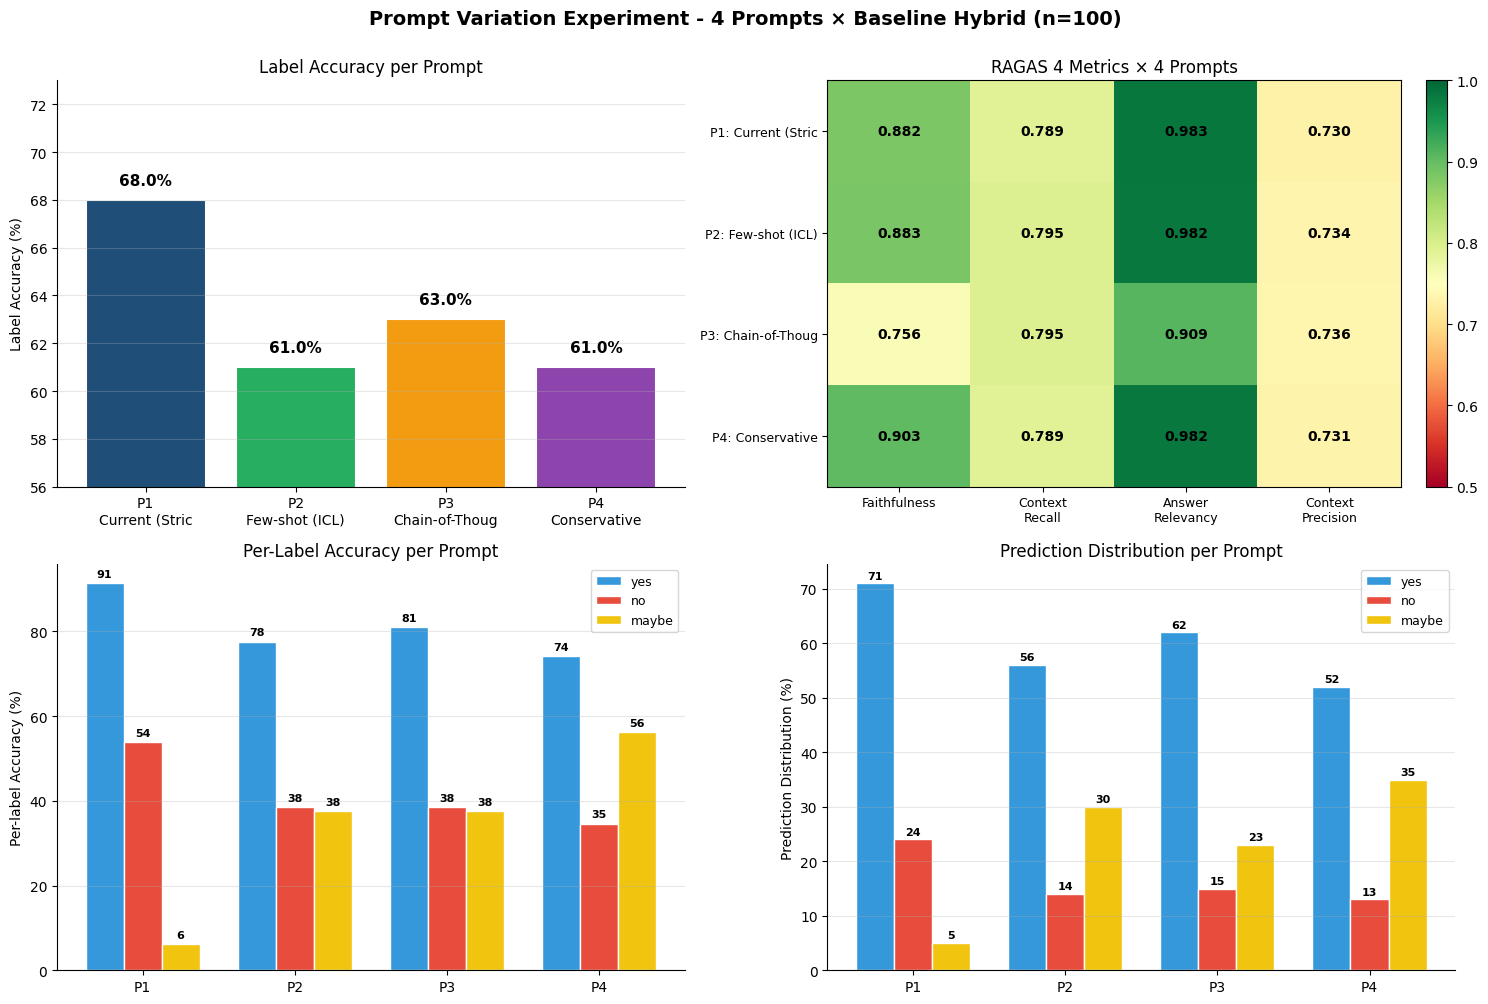


Saved: figures\K_prompt_variation.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Prompt Variation Experiment - 4 Prompts × Baseline Hybrid (n={MAX_SAMPLES})',
             fontsize=14, fontweight='bold', y=1.00)

# Color per prompt
prompt_colors = {
    'P1': '#1f4e79',  # navy (current)
    'P2': '#27ae60',  # green (few-shot)
    'P3': '#f39c12',  # orange (CoT)
    'P4': '#8e44ad',  # purple (conservative)
}

# Panel 1: Label Accuracy
ax = axes[0, 0]
pids   = list(summary.keys())
accs   = [summary[p]['acc']*100 for p in pids]
colors = [prompt_colors[p] for p in pids]
labels = [f'{p}\n{PROMPT_NAMES[p][:14]}' for p in pids]
bars = ax.bar(labels, accs, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Label Accuracy (%)')
ax.set_title('Label Accuracy per Prompt')
ax.set_ylim(min(accs) - 5 if accs else 0, max(accs) + 5 if accs else 100)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: RAGAS heatmap (4 prompts × 4 metrics)
ax = axes[0, 1]
metric_keys = ['f', 'cr', 'ar', 'cp']
metric_labels = ['Faithfulness', 'Context\nRecall', 'Answer\nRelevancy', 'Context\nPrecision']
matrix = np.array([[summary[p][k] for k in metric_keys] for p in pids])
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(metric_labels)))
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_yticks(range(len(pids)))
ax.set_yticklabels([f'{p}: {PROMPT_NAMES[p][:14]}' for p in pids], fontsize=9)
ax.set_title('RAGAS 4 Metrics × 4 Prompts')
for i in range(len(pids)):
    for j in range(len(metric_keys)):
        v = matrix[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=10,
                color='white' if v < 0.7 else 'black', fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Panel 3: Per-label accuracy stacked
ax = axes[1, 0]
labels_3 = ['yes', 'no', 'maybe']
x = np.arange(len(pids))
width = 0.25
for i, lbl in enumerate(labels_3):
    accs_lbl = []
    for pid in pids:
        sub = [r for r in phase1_data[pid] if r['ground_truth'] == lbl]
        if sub:
            accs_lbl.append(sum(r['is_correct'] for r in sub) / len(sub) * 100)
        else:
            accs_lbl.append(0)
    bars = ax.bar(x + i*width - width, accs_lbl, width, label=lbl,
                  color=['#3498db', '#e74c3c', '#f1c40f'][i], edgecolor='white', linewidth=1)
    for bar, v in zip(bars, accs_lbl):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pids)
ax.set_ylabel('Per-label Accuracy (%)')
ax.set_title('Per-Label Accuracy per Prompt')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 4: Prediction distribution
ax = axes[1, 1]
for i, lbl in enumerate(labels_3):
    pcts = []
    for pid in pids:
        results = phase1_data[pid]
        cnt = sum(1 for r in results if r['predicted_label'] == lbl)
        pcts.append(cnt / len(results) * 100)
    bars = ax.bar(x + i*width - width, pcts, width, label=lbl,
                  color=['#3498db', '#e74c3c', '#f1c40f'][i], edgecolor='white', linewidth=1)
    for bar, v in zip(bars, pcts):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(pids)
ax.set_ylabel('Prediction Distribution (%)')
ax.set_title('Prediction Distribution per Prompt')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
out_fig = FIGURES_DIR / 'K_prompt_variation.png'
plt.savefig(out_fig, dpi=200, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out_fig}')

## Cell 12 — Interpretation Helper: Prompt Recommendation

In [ ]:
# Determine recommended prompt
print('=' * 65)
print('REKOMENDASI PROMPT BERDASARKAN HASIL EKSPERIMEN')
print('=' * 65)

if not summary:
    print('No data — Phase 2 belum selesai.')
else:
    # Best by accuracy
    best_acc_pid = max(summary, key=lambda p: summary[p]['acc'])
    print(f'\n[1] Best by Label Accuracy : {best_acc_pid} ({PROMPT_NAMES[best_acc_pid]})')
    print(f'    Accuracy = {summary[best_acc_pid]["acc"]*100:.1f}%')

    # Best by faithfulness
    best_f_pid = max(summary, key=lambda p: summary[p]['f'])
    print(f'\n[2] Best by Faithfulness   : {best_f_pid} ({PROMPT_NAMES[best_f_pid]})')
    print(f'    Faithfulness = {summary[best_f_pid]["f"]:.4f}')

    # Best balanced (acc + faith)
    def balanced_score(p):
        return summary[p]['acc'] * 0.6 + summary[p]['f'] * 0.4
    best_bal_pid = max(summary, key=balanced_score)
    print(f'\n[3] Best Balanced (60% acc + 40% faith) : {best_bal_pid} ({PROMPT_NAMES[best_bal_pid]})')
    print(f'    Score = {balanced_score(best_bal_pid):.3f}')

    # Per-label winners
    print(f'\n[4] Per-label accuracy winners:')
    for lbl in ['yes', 'no', 'maybe']:
        accs_lbl = {}
        for pid in summary:
            sub = [r for r in phase1_data[pid] if r['ground_truth'] == lbl]
            if sub:
                accs_lbl[pid] = sum(r['is_correct'] for r in sub) / len(sub)
        if accs_lbl:
            best = max(accs_lbl, key=accs_lbl.get)
            print(f'    {lbl:<6} : {best} ({PROMPT_NAMES[best]}) = {accs_lbl[best]*100:.1f}%')

print('\n' + '=' * 65)
print('Untuk Bab VI Laporan TA, tabel rekomendasi:')
print('=' * 65)
print(f'\n  | Prompt | Acc | Faith | CR | AR | CP |')
print(f'  |--------|-----|-------|----|----|-----|')
for pid in PROMPT_IDS:
    if pid not in summary:
        continue
    s = summary[pid]
    print(f'  | {pid} ({PROMPT_NAMES[pid][:15]}) | {s["acc"]:.3f} | '
          f'{s["f"]:.3f} | {s["cr"]:.3f} | {s["ar"]:.3f} | {s["cp"]:.3f} |')